In [1]:
import sys
import os
import matplotlib.pyplot as plt
import time

sys.path.append(os.path.abspath('../common'))
from random_obstacles import DynamicObstacleGenerator
from DO_structs import *
from DO_graphics import *
from DO_searching import Map

%matplotlib inline

In [2]:
# Load the Control Set
cs = ControlSet()
cs.load_primitives("../data/control_set.txt")

# 1. Random Generation of Obstacle Trajectories

**Important note:** We intentionally ignore collisions between obstacles themselves and with static environment structures. Consequently, trajectories may overlap or intersect with map obstacles. We purposely bypassed this interaction to simplify test case generation (otherwise, we would have to solve a multi-agent pathfinding problem, which is unnecessary here). 

Furthermore, our core algorithm does not rely on these interactions: it simply needs to know the safe time-occupancy intervals for each individual grid cell. The specific relations or dependencies between obstacles are irrelevant to it. This approach actually provides a more robust validation: if the pathfinding algorithm succeeds in an environment where obstacles can conflict or clip through each other, it is guaranteed to perform seamlessly when they do not!

In [3]:
# Load the map grid where obstacle trajectories will be drafted
task_map = Map()
task_map.read_from_movingai_file("../maps/Denver_1_256.map")

In [4]:
# Configure the generator
generator = DynamicObstacleGenerator(
    control_set=cs, 
    task_map=task_map,
    prefix_to_save="../dynamic_obstacles/Denver_1_256_random/"
)

# Obstacle size distribution: 10 units with radius 1, and 2 units with radius 3
size_dist = {2: 100, 3: 100, 5: 100, 10: 30}

# Generate random paths (wandering) for the obstacles defined above.
# NOTE: If generation fails for a specific obstacle, it is simply skipped. 
# This is safe, as any missing obstacles can be re-generated later by running them separately.
generator.generate_batch(
    size_distribution=size_dist,
    min_length=100,       # Lower bound for trajectory length (expressed in the number of primitives)
    gen_type='random'     # Trajectories are randomized
)

⚠️ Failed to find a valid path for object 97
⚠️ Failed to find a valid path for object 235
⚠️ Failed to find a valid path for object 289
⚠️ Failed to find a valid path for object 303
⚠️ Failed to find a valid path for object 307


## Trajectory Visualization

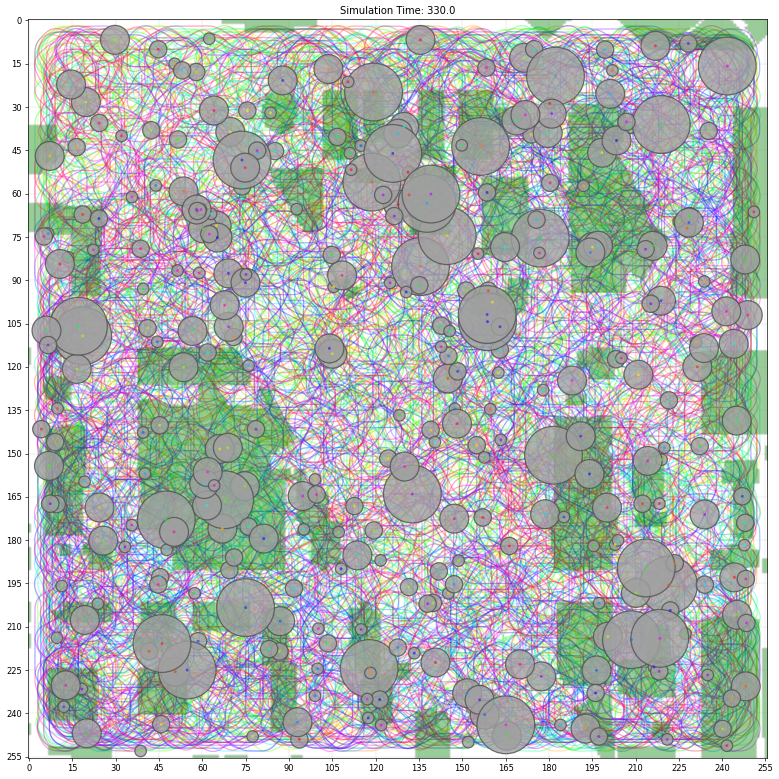

Saving GIF... Total frames compiled: 176
Simulation successfully saved to: ../media/denver_random_demo.gif


In [7]:
# 1. Initialization
# Load all autogenerated dynamic obstacle trajectories from the directory
obs_set = ObstacleSet().load_dynamic_obstacles("../dynamic_obstacles/Denver_1_256_random/dynamic_obstacle_*.txt", cs)

# 2. Instantiate the Visualizer Environment
update_sim, save_sim = create_dynamic_visualizer(
    task_map=task_map,
    obstacle_set=obs_set,
    show_path=True,
    fast_draw=True,
    make_gif=True,
    dpi=60,
    scale=2
)

# 3. Temporal Simulation Parameters
max_time = 330.0  # Total duration of the simulation in ticks
dt = 2            # Time step delta (controls animation speed and smoothness)
current_time = 0.0

# 4. Main Simulation Loop
while current_time <= max_time:
    update_sim(current_time)
    current_time += dt
    time.sleep(0.005)  # Micro-pause to allow the browser thread to render the frame smoothly

# 5. Export and Save Results
save_sim("../media/denver_random_demo.gif", fps=20)

# Generation of Circular Trajectories

In [10]:
# Давайте другую карту для примера возьмём
task_map = Map()
task_map.read_from_movingai_file("../maps/empty_64_64.map")

In [11]:
# Configure the generator
generator = DynamicObstacleGenerator(
    control_set=cs, 
    task_map=task_map,
    prefix_to_save="../dynamic_obstacles/empty_64_64_circle/"
)

# Obstacle size distribution (configured identically to the setup above)
size_dist = {1: 90}

generator.generate_batch(
    size_distribution=size_dist,
    min_length=100,       
    gen_type='circle'     # Generate circular trajectories
)

⚠️ Failed to find a valid path for object 71


## Trajectory Visualization

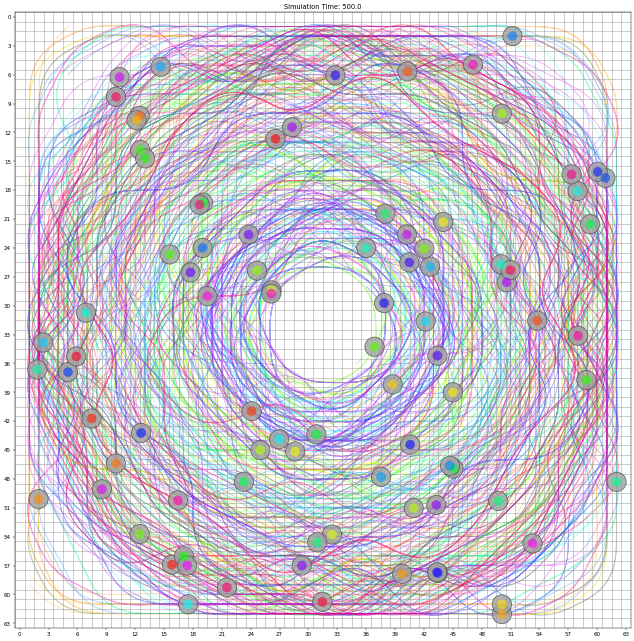

Saving GIF... Total frames compiled: 261
Simulation successfully saved to: ../media/empty_circle_demo.gif


In [17]:
# 1. Initialization
# Load all autogenerated dynamic obstacle trajectories from the directory
obs_set = ObstacleSet().load_dynamic_obstacles("../dynamic_obstacles/empty_64_64_circle/dynamic_obstacle_*.txt", cs)

# 2. Instantiate the Visualizer Environment
update_sim, save_sim = create_dynamic_visualizer(
    task_map=task_map,
    obstacle_set=obs_set,
    show_path=True,
    fast_draw=False,
    make_gif=True,
    dpi=40,
    scale=2
)

# 3. Temporal Simulation Parameters
max_time = 500.0
dt = 2
current_time = 0.0

# 4. Main Simulation Loop
while current_time <= max_time:
    update_sim(current_time)
    current_time += dt
    time.sleep(0.005)  # Micro-pause to allow the browser thread to render the frame smoothly

# 5. Export and Save Results
save_sim("../media/empty_circle_demo.gif", fps=20)